# 03 - CV Transformer Training + CV Extraction

Train a dedicated `cv_transformer` simulator (scalar bottleneck per CV token), then extract all CVs on the validation trajectories and plot them against final trajectory p-ratio.


In [15]:
import sys
from pathlib import Path

SRC_DIR = (Path.cwd().resolve() / '..' / 'src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Hard-reload local package modules so notebook always sees latest edits.
for name in list(sys.modules.keys()):
    if name == 'course_project' or name.startswith('course_project.'):
        del sys.modules[name]

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from graph_utils import calc_p_ratio_box

from course_project.config import ExperimentConfig
from course_project.runner import run_experiment
from course_project.data import load_dataset
from course_project.graph import build_graph
from course_project.models import create_model, resolve_model_inputs


In [ ]:

import random


seed = 56345
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# CV-transformer experiment config (adjust paths / sizes as needed)
common_cfg = dict(
    train_dataset='../data/data_aux_opt_lowT_448sims_noang_bidirect_train1.pt',
    val_dataset='../data/data_aux_opt_lowT_448sims_noang_bidirect_test244.pt',
    output_root='../results',
    device='cuda',
    pos_dim=2,
    history=1,
    node_features='positions',
    limit=20,
    hidden_size=128,
    n_layers=2,
    learning_rate=1e-7,
    learning_rate_decay=1,
    epochs=50,
    val_every=10,
    rollout_steps=50,
    cv_pratio_target='box',
    rollout_every=10,
    cv_eval_every=10,
    train_rollout_steps=1,
    train_rollout_loss_decay=1,
    freeze_normalizers_after_epoch=5,
    seed=seed
)

cfg_cv_transformer = ExperimentConfig(
    run_name='cv_transformer',
    model_type='cv_transformer',
    model_extras={
        'num_mlp': 3,
        'K1': 350,
        'CV': 4,              # number of scalar CVs
        'transformer_layers': 1,
        'transformer_heads': 1,
        'transformer_dropout': 0.0,
        'edge_aggr': 'mean',
        'use_local_skip': False,
    },
    **common_cfg,
)

metrics = run_experiment(cfg_cv_transformer)
pd.Series(metrics)


[run] cv_transformer model=cv_transformer device=cuda output=../results/cv_transformer
[run] training...
[train] autoregressive loss steps=1 decay=1
[ep  10/100] tr=1.01 va=1.09 lr=1e-07 roll=r2=-0.555 p=0.934 mse=3.44e-05 (244/244) cv=|p|=0.737 r2=0.543 (n=244) norm=fz n=(17,4148) t=41s
[ep  20/100] tr=1.01 va=1.09 lr=1e-07 roll=r2=-0.554 p=0.933 mse=3.4e-05 (244/244) cv=|p|=0.742 r2=0.551 (n=244) norm=fz n=(17,4148) t=40.4s


KeyboardInterrupt: 

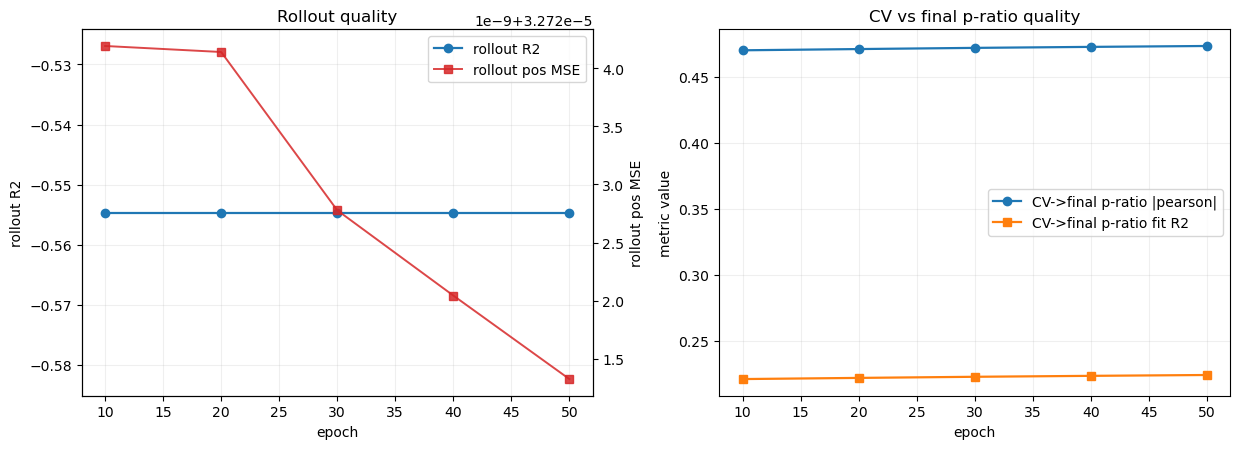

best rollout R2=-0.5547 at epoch 10
best CV abs_pearson_r=0.4733 at epoch 50 (n=244)
best CV fit R2=0.2240 at epoch 50 (n=244)


In [ ]:
# Post-training checkpoint metrics: rollout quality + CV->final p-ratio quality
import numpy as np
import matplotlib.pyplot as plt
import torch

run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
stats_path = run_dir / 'train_stats.pt'
if not stats_path.exists():
    raise RuntimeError(f'No train stats found at {stats_path}. Run the training cell first.')

stats = torch.load(stats_path, map_location='cpu', weights_only=False)
if not isinstance(stats, dict):
    raise RuntimeError('Loaded `train_stats.pt` is not a dict.')


def _series_from_stats(keys, n):
    if isinstance(keys, str):
        keys = [keys]
    vals = None
    for k in keys:
        if k in stats:
            vals = stats.get(k, [])
            break
    if vals is None:
        return np.full(n, np.nan, dtype=float)
    out = np.full(n, np.nan, dtype=float)
    for i, v in enumerate(vals[:n]):
        if v is None:
            continue
        try:
            out[i] = float(v)
        except Exception:
            out[i] = np.nan
    return out

n = len(stats.get('epoch', []))
if n == 0:
    raise RuntimeError('`stats` has no epochs. Check training output.')

epochs = np.asarray(stats['epoch'][:n], dtype=int)
rollout_r2 = _series_from_stats(['rollout_r2', 'val_rollout_r2'], n)
rollout_pos_mse = _series_from_stats(['rollout_pos_mse', 'val_rollout_pos_mse'], n)
cv_abs_r = _series_from_stats(['cv_abs_pearson_r', 'val_cv_pr_abs_pearson_r'], n)
cv_fit_r2 = _series_from_stats(['cv_fit_r2', 'val_cv_pr_fit_r2'], n)
cv_used = _series_from_stats(['cv_used', 'val_cv_pr_n'], n)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
m_r = np.isfinite(rollout_r2)
if m_r.any():
    ax.plot(epochs[m_r], rollout_r2[m_r], marker='o', linewidth=1.6, label='rollout R2')
ax.set_xlabel('epoch')
ax.set_ylabel('rollout R2')
ax.set_title('Rollout quality')
ax.grid(alpha=0.2)

ax2 = ax.twinx()
m_m = np.isfinite(rollout_pos_mse)
if m_m.any():
    ax2.plot(
        epochs[m_m], rollout_pos_mse[m_m], marker='s', linewidth=1.4,
        color='tab:red', alpha=0.85, label='rollout pos MSE'
    )
ax2.set_ylabel('rollout pos MSE')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
if len(lines1) + len(lines2) > 0:
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax = axes[1]
m_a = np.isfinite(cv_abs_r)
m_f = np.isfinite(cv_fit_r2)
if m_a.any():
    ax.plot(epochs[m_a], cv_abs_r[m_a], marker='o', linewidth=1.6, label='CV->final p-ratio |pearson|')
if m_f.any():
    ax.plot(epochs[m_f], cv_fit_r2[m_f], marker='s', linewidth=1.6, label='CV->final p-ratio fit R2')
ax.set_xlabel('epoch')
ax.set_ylabel('metric value')
ax.set_title('CV vs final p-ratio quality')
ax.grid(alpha=0.2)
if m_a.any() or m_f.any():
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

if m_r.any():
    i = int(np.nanargmax(rollout_r2))
    print(f'best rollout R2={rollout_r2[i]:.4f} at epoch {epochs[i]}')
if m_a.any():
    i = int(np.nanargmax(cv_abs_r))
    n_i = int(cv_used[i]) if np.isfinite(cv_used[i]) else -1
    print(f'best CV abs_pearson_r={cv_abs_r[i]:.4f} at epoch {epochs[i]} (n={n_i if n_i>=0 else "?"})')
if m_f.any():
    i = int(np.nanargmax(cv_fit_r2))
    n_i = int(cv_used[i]) if np.isfinite(cv_used[i]) else -1
    print(f'best CV fit R2={cv_fit_r2[i]:.4f} at epoch {epochs[i]} (n={n_i if n_i>=0 else "?"})')


In [ ]:
# Reload trained model and optionally select the best CV checkpoint (instead of best rollout).
run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
final_ckpt_path = run_dir / 'final_checkpoint.pt'
train_stats_path = run_dir / 'train_stats.pt'
rollout_ckpt_dir = run_dir / 'rollout_checkpoints'

# Options: 'best_cv_fit_r2', 'best_cv_abs_pearson_r', 'final_checkpoint'
checkpoint_selection = 'best_cv_fit_r2'

ckpt = torch.load(final_ckpt_path, map_location='cpu', weights_only=False)
cfg_loaded = ExperimentConfig(**ckpt['cfg'])

# Resolve runtime device safely.
device = cfg_loaded.device
if device == 'cuda' and not torch.cuda.is_available():
    device = 'cpu'

val_data = load_dataset(cfg_loaded.val_dataset)
init_frames = [val_data[0][i].to(device) for i in range(cfg_loaded.history + 1)]
init_graph = build_graph(input_graphs=init_frames, node_features=cfg_loaded.node_features).to(device)

model = create_model(
    model_type=cfg_loaded.model_type,
    init_graph=init_graph,
    pos_dim=cfg_loaded.pos_dim,
    hidden_size=cfg_loaded.hidden_size,
    n_layers=cfg_loaded.n_layers,
    extras=cfg_loaded.model_extras,
).to(device)

selected_source = 'final_checkpoint'
selected_metric = None
selected_epoch = None
selected_value = None

if checkpoint_selection != 'final_checkpoint' and train_stats_path.exists() and rollout_ckpt_dir.exists():
    stats = torch.load(train_stats_path, map_location='cpu', weights_only=False)
    metric_key = {
        'best_cv_fit_r2': 'cv_fit_r2',
        'best_cv_abs_pearson_r': 'cv_abs_pearson_r',
    }.get(checkpoint_selection)

    if metric_key is not None and metric_key in stats and 'epoch' in stats:
        rows = []
        for epoch, value in zip(stats.get('epoch', []), stats.get(metric_key, [])):
            if value is None:
                continue
            try:
                v = float(value)
            except (TypeError, ValueError):
                continue
            if not np.isfinite(v):
                continue
            ckpt_path = rollout_ckpt_dir / f'epoch_{int(epoch):04d}.pt'
            if not ckpt_path.exists():
                continue
            rows.append((int(epoch), v, ckpt_path))

        if rows:
            # Tie-break by later epoch, matching rollout checkpoint selection behavior.
            rows.sort(key=lambda t: (t[1], t[0]))
            selected_epoch, selected_value, selected_ckpt_path = rows[-1]
            model.load_checkpoint(str(selected_ckpt_path))
            selected_source = str(selected_ckpt_path)
            selected_metric = metric_key
        else:
            model.load_state_dict(ckpt['model_state_dict'], strict=False)
    else:
        model.load_state_dict(ckpt['model_state_dict'], strict=False)
else:
    model.load_state_dict(ckpt['model_state_dict'], strict=False)

model.eval()
model_inputs_cls = resolve_model_inputs(cfg_loaded.model_type)

print('Loaded model:', cfg_loaded.model_type, 'device=', device)
print('Run dir:', run_dir)
print('effective num CVs (CV):', cfg_loaded.model_extras['CV'])
print('checkpoint_selection:', checkpoint_selection)
if selected_metric is not None:
    print('selected best CV checkpoint:', selected_source)
    print('selected metric:', selected_metric, 'value=', selected_value, 'epoch=', selected_epoch)
else:
    print('selected checkpoint:', selected_source)


Loaded model: cv_transformer device= cuda
Run dir: ../results/cv_transformer
effective num CVs (CV): 2
checkpoint_selection: best_cv_fit_r2
selected best CV checkpoint: ../results/cv_transformer/rollout_checkpoints/epoch_0050.pt
selected metric: cv_fit_r2 value= 0.22397664177716303 epoch= 50


In [ ]:
# Extract trajectory-level CV summaries and final p-ratio.
# We average each CV over the observed trajectory frames [history, ..., min(rollout_steps, len(sim)-1)-1].
rows = []

with torch.no_grad():
    for sim_idx, sim in enumerate(val_data):
        n_local = min(cfg_loaded.rollout_steps, len(sim) - 1)
        if n_local <= cfg_loaded.history:
            continue

        final_pr = float(calc_p_ratio_box(sim, -1))
        if not np.isfinite(final_pr):
            continue

        cv_values = []
        for t in range(cfg_loaded.history, n_local):
            frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
            if t > 0:
                prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                cur_pos = frames[-1].x[:, : cfg_loaded.pos_dim]
                frames[-1].vel_state = cur_pos - prev_pos

            input_graph = build_graph(frames, node_features=cfg_loaded.node_features).to(device)
            cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
            cv = np.asarray(cv, dtype=float).reshape(-1)
            if cv.size == 0 or not np.all(np.isfinite(cv)):
                continue
            cv_values.append(cv)

        if not cv_values:
            continue

        cv_mean = np.mean(np.stack(cv_values, axis=0), axis=0)
        row = {
            'sim_idx': sim_idx,
            'num_frames_used': len(cv_values),
            'final_p_ratio': final_pr,
        }
        for i, value in enumerate(cv_mean, start=1):
            row[f'cv_{i}'] = float(value)
        rows.append(row)

df_cv = pd.DataFrame(rows).sort_values('sim_idx').reset_index(drop=True)
df_cv.head(), df_cv.shape


(   sim_idx  num_frames_used  final_p_ratio      cv_1      cv_2
 0        0               49      -0.592555  0.085847  0.085847
 1        1               49       0.242181 -0.054433 -0.054433
 2        2               49      -0.585679  0.087375  0.087375
 3        3               49      -0.480055 -0.131774 -0.131774
 4        4               49      -0.089249 -0.069691 -0.069691,
 (244, 5))

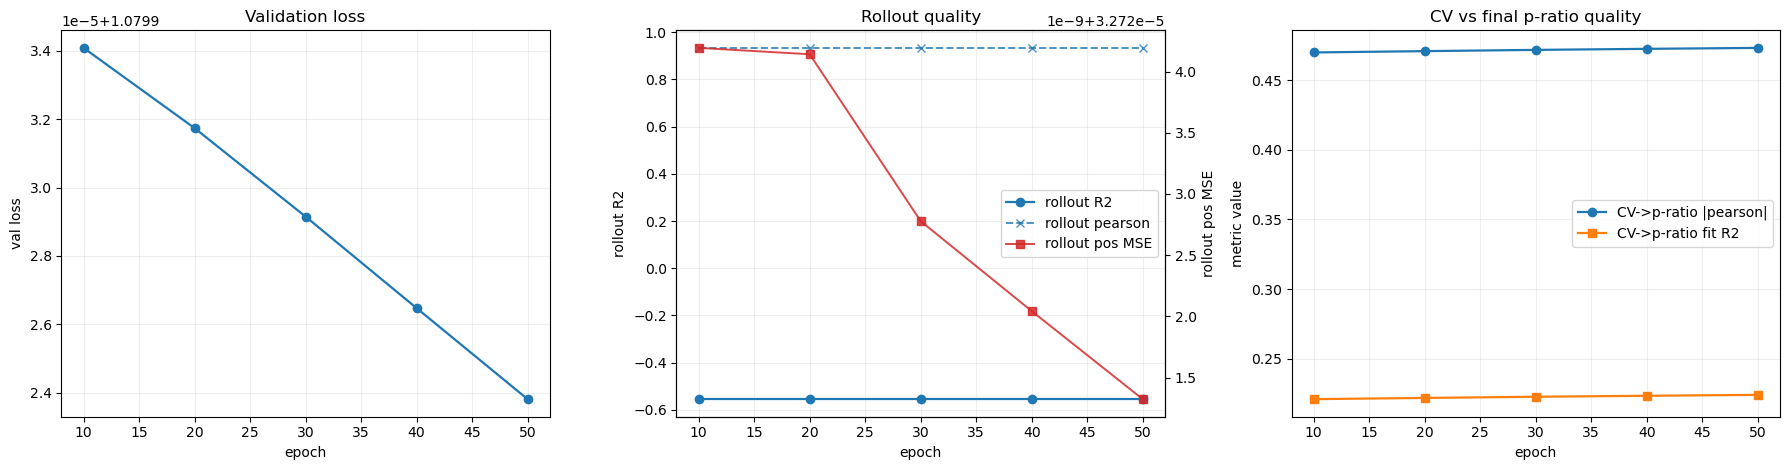

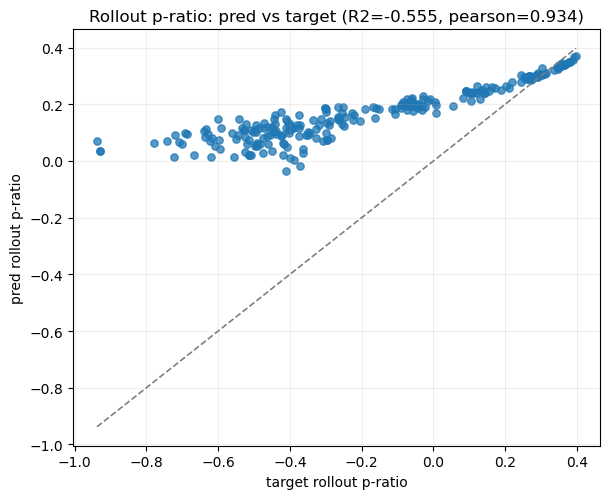

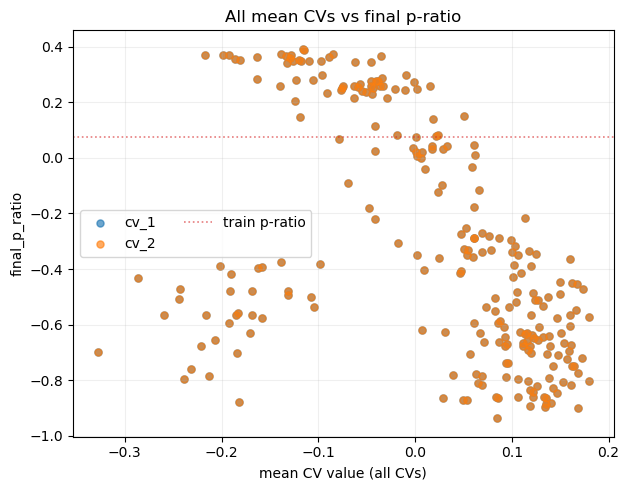

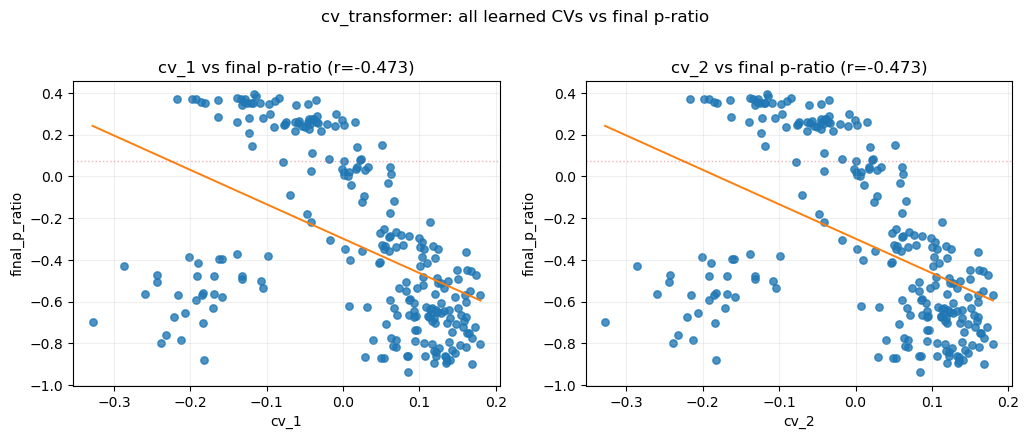

best val_loss=1.08 @ epoch 50
best rollout_r2=-0.555 @ epoch 10
best rollout_pos_mse=3.27e-05 @ epoch 50
best rollout_pearson_r=0.934 @ epoch 10
best cv_abs_pearson_r=0.473 @ epoch 50
best cv_fit_r2=0.224 @ epoch 50


In [ ]:
# Dashboard: val loss, rollout quality, CV-fit over epochs + all CVs vs final p-ratio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from course_project.data import load_dataset
from graph_utils import calc_p_ratio_box, calc_p_ratio_rollout_sides

run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
stats_path = run_dir / 'train_stats.pt'
if not stats_path.exists():
    raise RuntimeError(f'No train stats found at {stats_path}. Run the training cell first.')
if 'df_cv' not in globals() or not isinstance(df_cv, pd.DataFrame) or df_cv.empty:
    raise RuntimeError('No non-empty `df_cv` found. Run the CV extraction cell first.')

stats = torch.load(stats_path, map_location='cpu', weights_only=False)
if not isinstance(stats, dict):
    raise RuntimeError('Loaded `train_stats.pt` is not a dict.')


def _series_from_stats(keys, n):
    if isinstance(keys, str):
        keys = [keys]
    vals = None
    for k in keys:
        if k in stats:
            vals = stats.get(k, [])
            break
    if vals is None:
        return np.full(n, np.nan, dtype=float)
    out = np.full(n, np.nan, dtype=float)
    for i, v in enumerate(vals[:n]):
        if v is None:
            continue
        try:
            out[i] = float(v)
        except Exception:
            out[i] = np.nan
    return out

n = len(stats.get('epoch', []))
if n == 0:
    raise RuntimeError('`stats` has no epochs.')

epochs = np.asarray(stats['epoch'][:n], dtype=int)
val_loss = _series_from_stats('val_loss', n)
rollout_r2 = _series_from_stats(['rollout_r2', 'val_rollout_r2'], n)
rollout_pos_mse = _series_from_stats(['rollout_pos_mse', 'val_rollout_pos_mse'], n)
rollout_pearson_r = _series_from_stats(['rollout_pearson_r'], n)
cv_abs_r = _series_from_stats(['cv_abs_pearson_r', 'val_cv_pr_abs_pearson_r'], n)
cv_fit_r2 = _series_from_stats(['cv_fit_r2', 'val_cv_pr_fit_r2'], n)

# Figure 1: epoch curves (side-by-side)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

ax = axes[0]
m_v = np.isfinite(val_loss)
if m_v.any():
    ax.plot(epochs[m_v], val_loss[m_v], marker='o', linewidth=1.6, color='tab:blue')
ax.set_title('Validation loss')
ax.set_xlabel('epoch')
ax.set_ylabel('val loss')
ax.grid(alpha=0.2)

ax = axes[1]
m_r = np.isfinite(rollout_r2)
if m_r.any():
    ax.plot(epochs[m_r], rollout_r2[m_r], marker='o', linewidth=1.6, label='rollout R2', color='tab:blue')
ax.set_title('Rollout quality')
ax.set_xlabel('epoch')
ax.set_ylabel('rollout R2')
ax.grid(alpha=0.2)
m_rp = np.isfinite(rollout_pearson_r)
if m_rp.any():
    ax.plot(epochs[m_rp], rollout_pearson_r[m_rp], marker='x', linestyle='--', linewidth=1.4, label='rollout pearson', color='tab:blue', alpha=0.8)
ax2 = ax.twinx()
m_m = np.isfinite(rollout_pos_mse)
if m_m.any():
    ax2.plot(epochs[m_m], rollout_pos_mse[m_m], marker='s', linewidth=1.4, label='rollout pos MSE', color='tab:red', alpha=0.85)
ax2.set_ylabel('rollout pos MSE')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
if lines1 or lines2:
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax = axes[2]
m_a = np.isfinite(cv_abs_r)
m_f = np.isfinite(cv_fit_r2)
if m_a.any():
    ax.plot(epochs[m_a], cv_abs_r[m_a], marker='o', linewidth=1.6, label='CV->p-ratio |pearson|')
if m_f.any():
    ax.plot(epochs[m_f], cv_fit_r2[m_f], marker='s', linewidth=1.6, label='CV->p-ratio fit R2')
ax.set_title('CV vs final p-ratio quality')
ax.set_xlabel('epoch')
ax.set_ylabel('metric value')
ax.grid(alpha=0.2)
if m_a.any() or m_f.any():
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

# Figure 2: rollout p-ratio scatter (the points behind rollout R2 / Pearson)
rollout_pred_path = run_dir / 'rollout_predictions.csv'
if rollout_pred_path.exists():
    df_roll = pd.read_csv(rollout_pred_path)
    req_cols = {'target_rollout_sides_p_ratio', 'pred_rollout_p_ratio'}
    if req_cols.issubset(df_roll.columns):
        x = df_roll['target_rollout_sides_p_ratio'].to_numpy(dtype=float)
        y = df_roll['pred_rollout_p_ratio'].to_numpy(dtype=float)
        m_xy = np.isfinite(x) & np.isfinite(y)
        x = x[m_xy]
        y = y[m_xy]
        if x.size >= 2:
            fig, ax = plt.subplots(1, 1, figsize=(6.2, 5.1))
            ax.scatter(x, y, s=28, alpha=0.75)
            lo = float(min(np.min(x), np.min(y)))
            hi = float(max(np.max(x), np.max(y)))
            ax.plot([lo, hi], [lo, hi], color='tab:gray', linewidth=1.2, linestyle='--')
            title = 'Rollout p-ratio: pred vs target'
            if x.size >= 3 and np.std(x) > 1e-12 and np.std(y) > 1e-12:
                r = float(np.corrcoef(x, y)[0, 1])
                ss_res = float(np.sum((y - x) ** 2))
                ss_tot = float(np.sum((x - np.mean(x)) ** 2))
                r2 = float('nan') if ss_tot <= 1e-12 else 1.0 - ss_res / ss_tot
                title += f' (R2={r2:.3g}, pearson={r:.3g})'
        
            ax.set_title(title)
            ax.set_xlabel('target rollout p-ratio')
            ax.set_ylabel('pred rollout p-ratio')
            ax.grid(alpha=0.2)
            plt.tight_layout()
            plt.show()
        else:
            print('rollout_predictions.csv has too few finite rows for scatter.')
    else:
        print('rollout_predictions.csv missing required columns:', sorted(req_cols - set(df_roll.columns)))
else:
    print('No rollout_predictions.csv found at', rollout_pred_path)

cv_cols = [c for c in df_cv.columns if c.startswith('cv_')]
if not cv_cols:
    raise RuntimeError('No CV columns found in `df_cv`.')

y_all = df_cv['final_p_ratio'].to_numpy(dtype=float)


# Train-set p-ratio marker(s): horizontal references on CV plots.
train_target_kind = getattr(cfg_cv_transformer, 'cv_pratio_target', 'box')
train_p_ratios = []
for sim in load_dataset(cfg_cv_transformer.train_dataset):
    if train_target_kind == 'rollout_sides':
        y_tr = float(calc_p_ratio_rollout_sides(sim, -1))
    else:
        y_tr = float(calc_p_ratio_box(sim, -1))
    if np.isfinite(y_tr):
        train_p_ratios.append(y_tr)

# Figure 3: combined scatter (all mean CVs vs final p-ratio)
fig, ax = plt.subplots(1, 1, figsize=(6.4, 5.0))
for j, col in enumerate(cv_cols):
    x = df_cv[col].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y_all)
    if not np.any(mask):
        continue
    ax.scatter(x[mask], y_all[mask], s=26, alpha=0.65, label=col)
ax.set_title('All mean CVs vs final p-ratio')
ax.set_xlabel('mean CV value (all CVs)')
ax.set_ylabel('final_p_ratio')
ax.grid(alpha=0.2)

for k, y_tr in enumerate(train_p_ratios):
    ax.axhline(y_tr, color='tab:red', linestyle=':', linewidth=1.2, alpha=0.6,
               label='train p-ratio' if k == 0 else None)
if len(cv_cols) <= 10:
    ax.legend(loc='best', ncol=min(3, len(cv_cols)))
plt.tight_layout()
plt.show()

# Figure 4: all CVs vs final p-ratio (side-by-side/grid)
n_cv = len(cv_cols)
ncols = min(3, n_cv)
nrows = int(np.ceil(n_cv / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.3 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cv_cols):
    x = df_cv[col].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y_all)
    x = x[mask]
    y = y_all[mask]
    ax.scatter(x, y, s=28, alpha=0.8)
    title = f'{col} vs final p-ratio'
    if x.size >= 3 and np.std(x) > 1e-12 and np.std(y) > 1e-12:
        r = float(np.corrcoef(x, y)[0, 1])
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(float(x.min()), float(x.max()), 100)
        ax.plot(xs, slope * xs + intercept, linewidth=1.4, color='tab:orange')
        title += f' (r={r:.3f})'
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('final_p_ratio')
    ax.grid(alpha=0.2)
    for y_tr in train_p_ratios:
        ax.axhline(y_tr, color='tab:red', linestyle=':', linewidth=1.0, alpha=0.35)

for ax in axes_flat[len(cv_cols):]:
    ax.axis('off')

fig.suptitle(f"{cfg_cv_transformer.run_name}: all learned CVs vs final p-ratio", y=1.01)
plt.tight_layout()
plt.show()

# Compact best-epoch summary
if m_v.any():
    i = int(np.nanargmin(val_loss))
    print(f'best val_loss={val_loss[i]:.3g} @ epoch {epochs[i]}')
if m_r.any():
    i = int(np.nanargmax(rollout_r2))
    print(f'best rollout_r2={rollout_r2[i]:.3g} @ epoch {epochs[i]}')
if m_m.any():
    i = int(np.nanargmin(rollout_pos_mse))
    print(f'best rollout_pos_mse={rollout_pos_mse[i]:.3g} @ epoch {epochs[i]}')
if m_rp.any():
    i = int(np.nanargmax(rollout_pearson_r))
    print(f'best rollout_pearson_r={rollout_pearson_r[i]:.3g} @ epoch {epochs[i]}')
if m_a.any():
    i = int(np.nanargmax(cv_abs_r))
    print(f'best cv_abs_pearson_r={cv_abs_r[i]:.3g} @ epoch {epochs[i]}')
if m_f.any():
    i = int(np.nanargmax(cv_fit_r2))
    print(f'best cv_fit_r2={cv_fit_r2[i]:.3g} @ epoch {epochs[i]}')


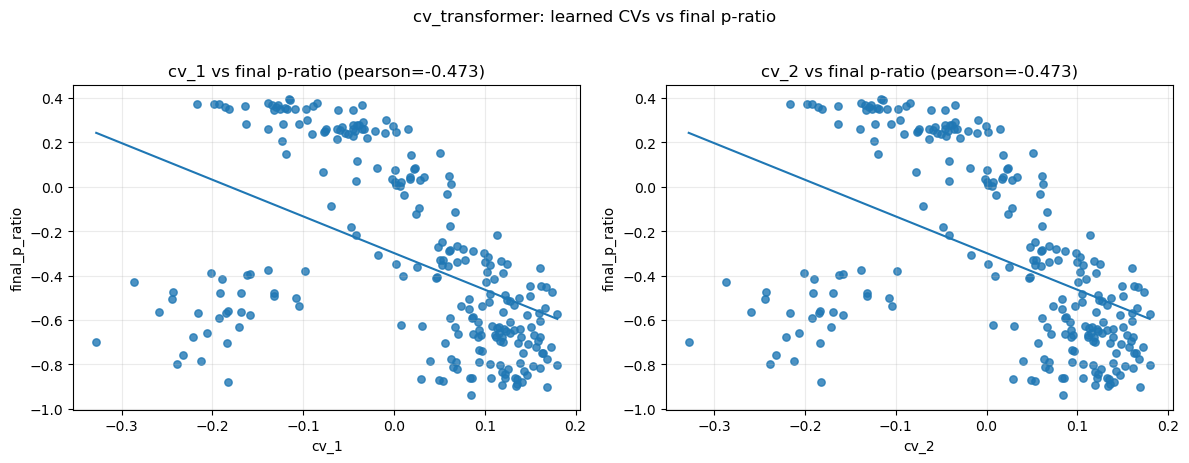

Saved: ../results/cv_transformer/cv_transformer_cvs_vs_final_pratio.csv
Saved: ../results/cv_transformer/cv_transformer_cvs_vs_final_pratio.png
final_p_ratio    1.000000
cv_1            -0.473262
cv_2            -0.473262
Name: final_p_ratio, dtype: float64


In [ ]:
# Plot each learned CV against final p-ratio and save outputs to the run folder.
cv_cols = [c for c in df_cv.columns if c.startswith('cv_')]
if not cv_cols:
    raise ValueError('No CV columns found in extracted dataframe.')

n = len(cv_cols)
ncols = 2 if n > 1 else 1
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cv_cols):
    x = df_cv[col].to_numpy(dtype=float)
    y = df_cv['final_p_ratio'].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, s=28, alpha=0.8)
    if x.size >= 2 and np.std(x) > 1e-12 and np.std(y) > 1e-12:
        r = float(np.corrcoef(x, y)[0, 1])
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(float(x.min()), float(x.max()), 100)
        ax.plot(xs, slope * xs + intercept, linewidth=1.5)
        ax.set_title(f'{col} vs final p-ratio (pearson={r:.3f})')
    else:
        ax.set_title(f'{col} vs final p-ratio')
    ax.set_xlabel(col)
    ax.set_ylabel('final_p_ratio')
    ax.grid(alpha=0.25)

for ax in axes_flat[len(cv_cols):]:
    ax.axis('off')

fig.suptitle(f"{cfg_loaded.run_name}: learned CVs vs final p-ratio", y=1.02)
fig.tight_layout()

csv_path = run_dir / 'cv_transformer_cvs_vs_final_pratio.csv'
png_path = run_dir / 'cv_transformer_cvs_vs_final_pratio.png'
df_cv.to_csv(csv_path, index=False)
fig.savefig(png_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved:', csv_path)
print('Saved:', png_path)
print(df_cv[cv_cols + ['final_p_ratio']].corr()['final_p_ratio'].sort_values(ascending=False))
